# Tutorial 1: Harmonic Heat Flow
In this example, we implement a _norm-conservative method_ for the harmonic heat flow into the sphere based on the repo [harmonic_heat_flow](https://github.com/Max-Reiter-math/harmonic_heat_flow/blob/master/sim/models/nonlin_cg.py). More mathematical details of this method applied to a liquid crystal model can be found in [Lasarzik, R., Reiter, M.E.V. Analysis and Numerical Approximation of Energy-Variational Solutions to the Ericksen–Leslie Equations. Acta Appl Math 184, 11 (2023).](https://doi.org/10.1007/s10440-023-00563-9)

Main contents:
- Introduction,
- implementation of a non-linear problem using a monolithic Newton solver.

On the domain $\Omega \subset \mathbb{R}^{N}$, we denote the director field (local average of the molecules' orientation) by $d: [0,T] \times \overline{\Omega} \to \mathbb{R}^{N}$.
The harmonic heat flow into the sphere is governed by the equations
$$
\begin{aligned}
    \partial_t  d 
    -
    \gamma \Delta d - \gamma \vert \nabla  d \vert^2  d
    &=  0 \, ,
    \\
     \vert  d \vert^2 &= 1 \, .
\end{aligned}
$$
For all functions $d \in H^2(\Omega;\mathbb{S}^{N-1})$, we observe the identity
$$
-
\Delta  d 
- \vert \nabla d \vert^2 d
=
-
(\mathrm{I} - d \otimes d) \Delta d 
\, .
$$
The reformulated governing equations read as
$$
\begin{aligned}
    \partial_t  d 
    -
    \gamma
    (\mathrm{I} - d \otimes d) \Delta d 
    &=  0 \, ,
    \\
     \vert d \vert^2 &= 1 \, .
\end{aligned}
$$
We equip the system with standard initial and homogeneous Neumann boundary conditions,
$$
d(0) = d_0 \in H^2(\Omega;\mathbb{S}^{N-1}) , \qquad [\nabla d ] \eta_{\partial \Omega} = 0 \text{ on }\partial \Omega \, . 
$$

## Step 1: Mesh Generation
We create the domain $\Omega = (-1,1)^2$.

In [1]:
import numpy as np
from dolfinx.mesh import create_rectangle, CellType
from dolfinx.cpp.mesh import DiagonalType
from mpi4py import MPI

dim = 2
n   = 10

domain = create_rectangle(MPI.COMM_WORLD, [np.array([-1.0, -1.0]), np.array([1.0, 1.0])],  [n, n], cell_type = CellType.triangle, diagonal=DiagonalType.left_right)

### Optional: Visualization using Pyvista

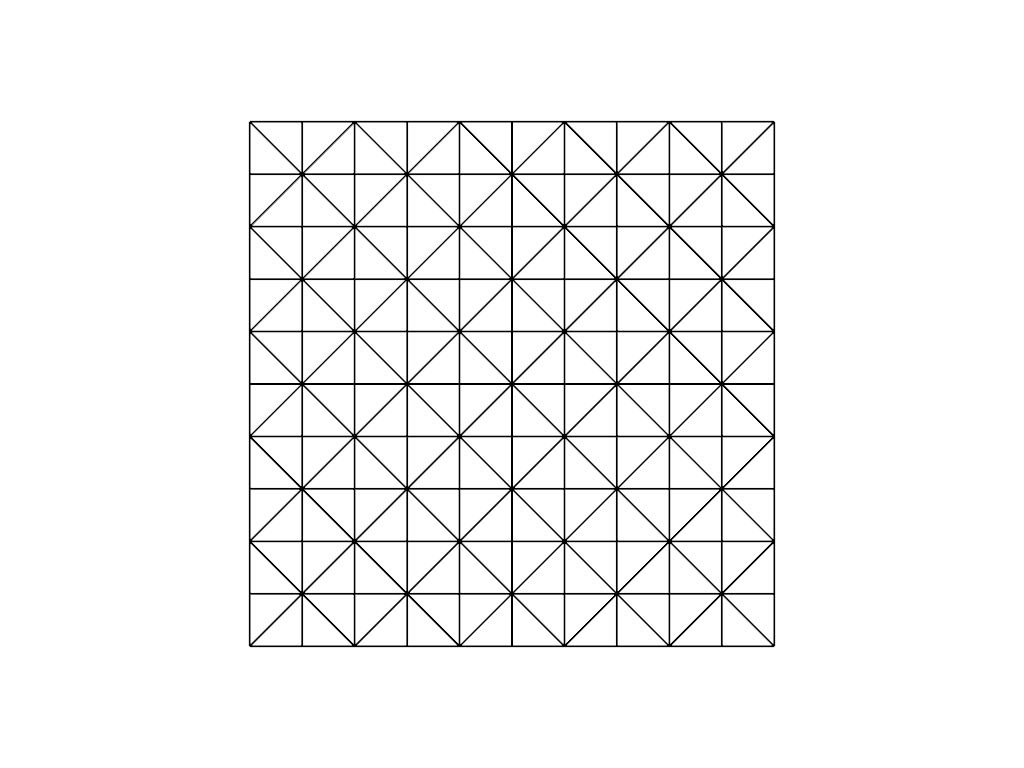

In [2]:

import pyvista
import dolfinx.plot as plot

domain.topology.create_connectivity(dim, dim)
topology, cell_types, geometry = plot.vtk_mesh(domain, dim)     # read mesh geometry
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry) # build grid

plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe", color="black", line_width=2)
plotter.view_xy()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("t1-mesh.png")

## Step 2: Initialization of Function Spaces and Functions
We employ globally continuous, affine-linear elements (CG1) for the director field. Its consistent approximation of the Laplacian is achieved using again globally continuous, affine-linear elements (CG1) for an auxiliary variable $q = - \Delta d$. To do so, we build a mixed finite element space.

In [3]:
from basix.ufl import element, mixed_element
from ufl import TestFunction, split
from dolfinx.fem import Function, functionspace

vP1         = element("CG", domain.basix_cell(), 1, shape=(dim,)) # vector-valued
me          = mixed_element([vP1, vP1])
FS          = functionspace(domain, me)

u1          = Function(FS)      # unknowns / next iterate
d1, q1      = split(u1)
u0          = Function(FS)      # knowns / initial conditions
d0, q0      = split(u0)
u_test      = TestFunction(FS)  # test functions
c, b        = split(u_test)

Moreover, we introduce the midpoint discretization for the director field $d$. The midpoint discretization of the variational derivative of the elastic energy $q$ is enforced in the mixed formulation.

In [4]:
d_ = 0.5*d1 + 0.5*d0

## Step 3: Variational Formulation
In order to employ the norm-conservation properties of the midpoint discretization, we define a discrete inner product on the $[CG1_h]^N$ finite element space - usually referred to as _mass-lumping_ - by
$$
( f_h, g_h)_h 
=
\int_{\Omega} \mathcal{I}_h^1 ( f_h \cdot  g_h) \mathrm{d} x
=
\sum_{{z} \in \mathcal{N}}  f_h ({z}) \cdot  g_h ({z}) \int_{\Omega} \Phi_{{z}} \mathrm{d} x
\, .
$$
In FEniCSx this is achieved using a quadrature rule:

In [5]:
from ufl import Measure
dxL = Measure("dx", domain = domain, metadata = {"quadrature_rule": "vertex", "quadrature_degree": 0})

Now, we can define the variational formulation of the weak problem given for $j=1,2,...$ by
$$
\begin{aligned}
\frac{1}{k} (d^j - d^{j-1}, c_h)_h
-
\gamma
([\mathrm{I} \vert d^{j-1/2}\vert^2 - d^{j-1/2} \otimes d^{j-1/2}] q^j, c_h)_h
&=  0 \, ,\\
(q^j, b_h)_h - (\nabla d^{j-1/2}, \nabla b_h)_2 
&=  0 \, ,
\end{aligned}
$$
for all test functions $(b_h, c_h) \in [CG1_h]^N\times [CG1_h]^N$ and with time-step size $k>0$. The quantity $q = - \Delta d$ is here implemented as a mixed method and to be solved simultaneously. The midpoint plus mass-lumped scheme preserves the nodal unit-length constraint in the discrete sense, provided the nonlinear system is solved accurately. In FEniCSx the variational formulation of the above equation system can be implemented using the _unified form language_ (UFL):

In [6]:
from ufl import inner, dx, grad
from dolfinx.fem.petsc import NonlinearProblem

k       = 0.1
gamma   = 1.0

eq = 1/k * inner(d1 - d0, c) *dxL                                                   # time derivative
eq += gamma * inner(d_,d_)*inner(q1,c)*dxL - gamma * inner(d_,q1)*inner(d_,c)*dxL   # damping term
eq += inner(q1, b)*dxL - inner(grad(d_), grad(b))*dx                                # definition of the auxiliary variable q

hhf = NonlinearProblem(eq, u1, bcs=[])

The homogeneous Neumann boundary conditions are implicitly defined by the variational formulation of $(q^j, b_h)_h - (\nabla d^{j-1/2}, \nabla b_h)_2 $, since the integration-by-parts formula yields
$$
\int_{\Omega}  -\Delta d \cdot \phi \mathrm{d}x
=
\int_{\Omega}  \nabla d : \nabla \phi \mathrm{d}x
-
\int_{\partial \Omega}  \nabla d : \phi \otimes \eta_{\partial \Omega} \mathrm{d}s
\, .
$$

## Step 4: Initial Values
We initialize only the director field $d$ as the initial variational derivative of the elastic energy $q^0$ does not show up in the variational formulation. Moreover, we initialize $d^1$ as initial guess for the non-linear solver. The initial director field is given by
$$
d_0 (x) = (\sin (\theta (x)), \cos (\theta (x)))^T \text{ with } \theta (x) = 2 \pi (\cos (x_1) - \sin (x_2))\,.
$$

In [7]:
def get_d0(x: np.ndarray)-> np.ndarray:
    # x has shape (dimension, points)
    values = np.zeros((dim, x.shape[1])) # values is going to be the output
    
    # Setting defects
    values[0]= np.sin( 2.0*np.pi*(np.cos(x[0])-np.sin(x[1]) ) )
    values[1]= np.cos( 2.0*np.pi*(np.cos(x[0])-np.sin(x[1]) ) )

    # renormalization
    norms = np.linalg.norm(values, ord = 2, axis = 0) # compute euclidean norm
    values = values / norms # renormalize
    return values

u0.sub(0).interpolate(get_d0)
u1.sub(0).interpolate(get_d0) 

## Step 5: Setup before the Time Evolution
Our variational formulation is highly non-linear. We employ a monolithic Newton solver to solve it.

In [8]:
from dolfinx.nls.petsc import NewtonSolver

solver = NewtonSolver(MPI.COMM_WORLD, hhf)

solver.convergence_criterion = "residual" # "residual" or "incremental"
solver.atol = 1e-6
solver.rtol = 1e-5
solver.max_it = 100
solver.error_on_nonconvergence = True
solver.report = True

Setup Output Pipeline for the director field, compute and save the elastic energy for $t = 0$.

In [9]:
from dolfinx.fem import form, assemble_scalar
from dolfinx.io import XDMFFile

xdmf = XDMFFile(MPI.COMM_WORLD, 't1-d.xdmf', "w")
xdmf.write_mesh(domain)
xdmf.write_function(u0.sub(0), 0.0)

print("Time: 0.0.")
energy = assemble_scalar(form(   0.5 *  inner(grad(d0), grad(d0))*dx   ))
print(f"Elastic Energy: {energy}.")

Time: 0.0.
Elastic Energy: 71.74653568132717.


## Step 6: Temporal Evolution

In [ ]:
t = 0.0
T = 1.0

while t < T:
    t += k 
    print(f"Time Step: {t}.")

    # solve equation system
    newton_iterations, converged = solver.solve(u1)
    print(f"Newton Solver - Converged: {converged}. Iterations: {newton_iterations}.")
    assert (converged)

    # update director field and variational derivative of the elastic energy
    u0.x.array[:] = u1.x.array[:]

    # compute isotropic elastic / Dirichlet energy
    energy = assemble_scalar(form(   0.5 *  inner(grad(d1), grad(d1))*dx   ))
    print(f"Elastic Energy: {energy}.")

    # save to file
    xdmf.write_function(u0.sub(0), t)

xdmf.close()

Time Step: 0.1.
Newton Solver - Converged: True. Iterations: 4.
Elastic Energy: 40.109721004220916.
Time Step: 0.2.
Newton Solver - Converged: True. Iterations: 4.
Elastic Energy: 25.939581258940116.
Time Step: 0.30000000000000004.
Newton Solver - Converged: True. Iterations: 3.
Elastic Energy: 17.111732142819804.
Time Step: 0.4.
Newton Solver - Converged: True. Iterations: 3.
Elastic Energy: 11.125342886035982.
Time Step: 0.5.
Newton Solver - Converged: True. Iterations: 3.
Elastic Energy: 7.104489441522735.
Time Step: 0.6.
Newton Solver - Converged: True. Iterations: 3.
Elastic Energy: 4.471208233611819.
Time Step: 0.7.
Newton Solver - Converged: True. Iterations: 3.
Elastic Energy: 2.785854683116964.
Time Step: 0.7999999999999999.
Newton Solver - Converged: True. Iterations: 2.
Elastic Energy: 1.724326593703891.
Time Step: 0.8999999999999999.
Newton Solver - Converged: True. Iterations: 2.
Elastic Energy: 1.0628379523296978.
Time Step: 0.9999999999999999.
Newton Solver - Converged: 